In [1]:
!pip install yfinance sqlalchemy

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

project_path = "/content/drive/MyDrive/mining-commodity-analysis"
os.makedirs(f"{project_path}/data/raw", exist_ok=True)
os.makedirs(f"{project_path}/data/processed", exist_ok=True)
os.makedirs(f"{project_path}/sql", exist_ok=True)

print("Project folder ready at:", project_path)

Project folder ready at: /content/drive/MyDrive/mining-commodity-analysis


In [6]:
import yfinance as yf
import pandas as pd

tickers = {
    "commodity": "HG=F",
    "FCX": "FCX",
    "SCCO": "SCCO",
    "BHP": "BHP"
}

data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start="2018-01-01", end="2026-07-01")
    data[name] = df[["Close"]].rename(columns={"Close": name})

data["FCX"].head()

/tmp/ipykernel_1224/1084725511.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2018-01-01", end="2026-07-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1224/1084725511.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2018-01-01", end="2026-07-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1224/1084725511.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2018-01-01", end="2026-07-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1224/1084725511.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2018-01-01", end="2026-07-01")
[*********************100%***********************]  1 of 1 completed


Price,FCX
Ticker,FCX
Date,
2018-01-02,17.805569
2018-01-03,17.535374
2018-01-04,17.778545
2018-01-05,17.922651
2018-01-08,17.841589


In [7]:
for name, df in data.items():
    df.to_csv(f"{project_path}/data/raw/{name}.csv")

print("Raw files saved.")

Raw files saved.


In [8]:
merged = pd.concat(data.values(), axis=1, join="inner")
merged.columns = data.keys()
merged = merged.dropna()
merged.index.name = "date"

merged.head()

,commodity,FCX,SCCO,BHP
date,,,,
2018-01-02,3.2560,17.805569,32.563198,24.648436
2018-01-03,3.2370,17.535374,32.623119,24.746984
2018-01-04,3.2425,17.778545,32.456657,24.793669
2018-01-05,3.2070,17.922651,32.709690,24.970028
2018-01-08,3.2010,17.841589,32.862862,25.156755


In [9]:
print("Total rows:", len(merged))
print("Date range:", merged.index.min(), "to", merged.index.max())

# Expected rough count: ~250 trading days per year
years = (merged.index.max() - merged.index.min()).days / 365
print("Years covered:", round(years, 1))
print("Expected rows (approx):", round(years * 250))

Total rows: 2133
Date range: 2018-01-02 00:00:00 to 2026-06-30 00:00:00
Years covered: 8.5
Expected rows (approx): 2124


In [10]:
# Reset index so 'date' is a column
merged_reset = merged.reset_index()

# Calculate the gap between consecutive dates
merged_reset["gap_days"] = merged_reset["date"].diff().dt.days

# Flag anything bigger than a normal long weekend (>4 days)
big_gaps = merged_reset[merged_reset["gap_days"] > 4]
print("Number of unusual gaps:", len(big_gaps))
big_gaps

Number of unusual gaps: 0


,date,commodity,FCX,SCCO,BHP,gap_days


In [11]:
# Calculate daily % change for each column
pct_changes = merged.pct_change()

# Flag any single-day move bigger than 15% (unusual for these stocks)
threshold = 0.15
spikes = pct_changes[(pct_changes.abs() > threshold).any(axis=1)]
print("Number of days with big spikes:", len(spikes))
spikes

Number of days with big spikes: 8


,commodity,FCX,SCCO,BHP
date,,,,
2020-03-09,-0.019044,-0.127253,-0.081756,-0.164790
2020-03-12,-0.012341,-0.116995,-0.156993,-0.127504
2020-03-16,-0.030517,-0.171315,-0.056675,-0.079907
2020-03-18,-0.066940,-0.180556,-0.071352,-0.112418
2020-03-24,0.036801,0.296846,0.129197,0.149433
2025-04-09,0.011629,0.155084,0.116224,0.102685
2025-07-31,-0.222531,0.028104,0.039982,0.000395
2025-09-24,0.036645,-0.169533,0.083802,0.003941


In [12]:
# Look at the raw commodity price around that date
print(merged.loc["2025-07-25":"2025-08-05", "commodity"])

date
2025-07-25    5.7635
2025-07-28    5.5950
2025-07-29    5.6035
2025-07-30    5.5700
2025-07-31    4.3305
2025-08-01    4.4125
2025-08-04    4.4150
2025-08-05    4.3640
Name: commodity, dtype: float64


In [14]:
returns = merged.pct_change().dropna()
print("Shape:", returns.shape)

Shape: (2132, 4)


In [15]:
returns.loc["2025-07-31", "commodity"] = None
returns = returns.dropna()
print("Cleaned. New shape:", returns.shape)

Cleaned. New shape: (2131, 4)


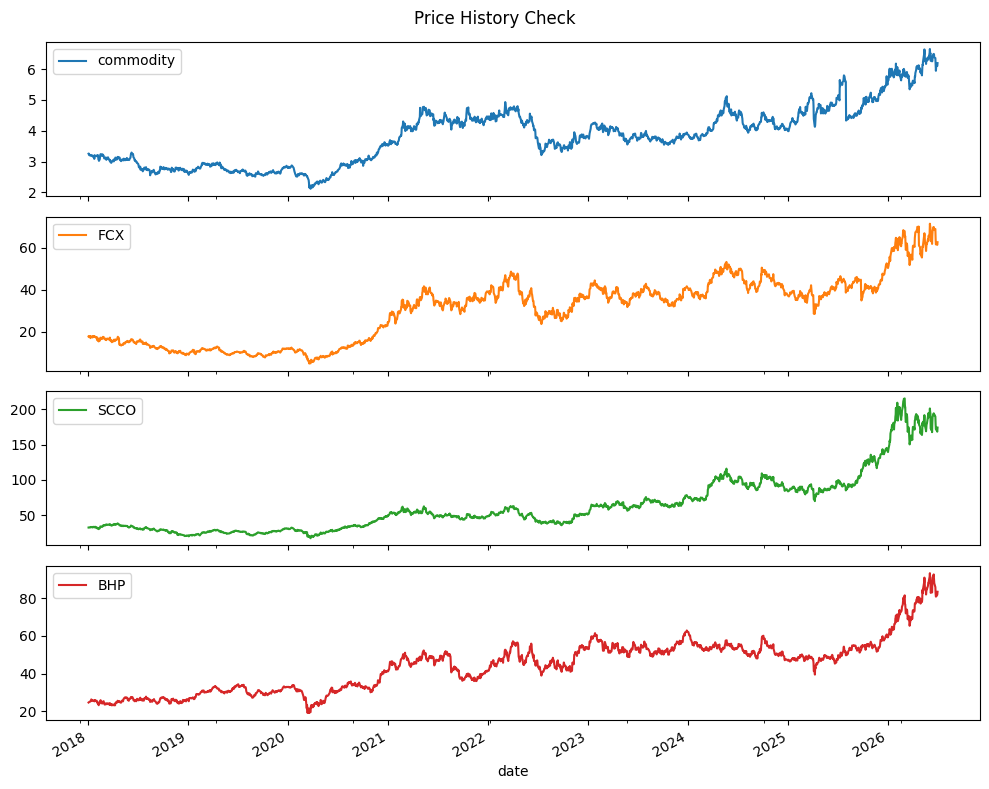

In [16]:
import matplotlib.pyplot as plt

merged.plot(subplots=True, figsize=(10, 8), title="Price History Check")
plt.tight_layout()
plt.show()

In [17]:
merged.to_csv(f"{project_path}/data/processed/merged_prices.csv")
print("Merged file saved. Shape:", merged.shape)

Merged file saved. Shape: (2133, 4)


In [18]:
from sqlalchemy import create_engine

db_path = f"{project_path}/mining_project.db"
engine = create_engine(f"sqlite:///{db_path}")

merged.to_sql("prices", engine, if_exists="replace")
print("Data loaded into SQL database.")

Data loaded into SQL database.


In [19]:
merged.to_csv(f"{project_path}/data/processed/prices.csv")
returns.to_csv(f"{project_path}/data/processed/returns.csv")

print("Files exported to:", f"{project_path}/data/processed/")

Files exported to: /content/drive/MyDrive/mining-commodity-analysis/data/processed/
